In [1]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [10]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential

import warnings
warnings.filterwarnings('ignore')

In [36]:
#handwritten digits dataset (0–9) 

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [37]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [38]:
X_train.shape

(60000, 28, 28)

In [15]:
y_train.shape

(60000,)

In [16]:
X_test.shape

(10000, 28, 28)

In [17]:
y_test.shape

(10000,)

In [18]:
 print(keras.datasets.mnist.load_data())
 print(len(keras.datasets.mnist.load_data()))

((array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ...

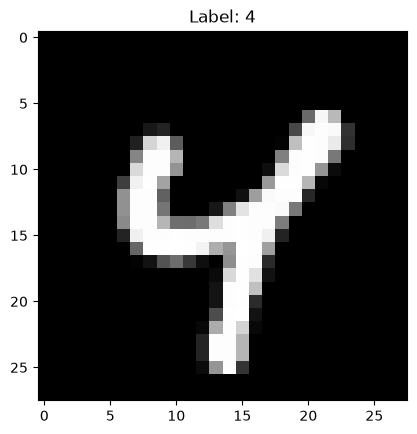

In [19]:
# Lets see visually how digit looks like

plt.imshow(X_train[1008], cmap='gray')
plt.title(f"Label: {y_train[1008]}")
plt.show()

In [20]:
X_train[1008]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [ ]:
# 🟢 Pixel values
# MNIST dataset मधल्या प्रत्येक image हा 28 × 28 grayscale matrix आहे.

# प्रत्येक pixel value 0 ते 255 range मध्ये असतो.

# 0 = काळा (black)

# 255 = पांढरा (white)

# मधल्या values = shades of gray

# 🟢 Normalisation का?
# Neural networks ला मोठे values (0–255) दिले तर learning unstable होते.
# त्यामुळे data scale करून 0–1 range मध्ये आणतो.

# 👉 Formula:

# Normalized value
# =
# Pixel value
# 255.0


# उदा.:

# Pixel = 0 → Normalized = 0.0

# Pixel = 128 → Normalized ≈ 0.5

# Pixel = 255 → Normalized = 1.0

# 🟢 फायदे
# Stable training → values छोटे असल्यामुळे gradient descent नीट काम करतं.

# Faster convergence → model लवकर शिकतो.

# Better accuracy → neural network generalize चांगलं करतं.

In [21]:
# Lets normalise the data , in this case need to divide data by 255.0
# Large values → unstable learning
# So we scale to: 0 to 1
# Neural networks learn better with smaller values also improves accuracy

X_train = X_train / 255.0   # converts values between 0 and 1
X_test = X_test / 255.0     # converts values between 0 and 1

In [22]:
X_train[1008]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [23]:
# ANN doesn’t understand images directly → we convert to vector
# so need to convert image (28x28) into 1D vector
# (not dataset, it will be 2D)

X_train_flattened = X_train.reshape(-1, 784) 
X_test_flattened = X_test.reshape(-1, 784)

In [42]:
#  -1 → Python ला आपोआप किती rows आहेत ते ठरवू दे (train मध्ये 60,000, test मध्ये 10,000).
# 🟢 Flattened image
# Neural Network (ANN) ला matrix directly समजत नाही, त्याला 1D vector लागतो.

# म्हणून आपण 28 × 28 = 784 pixels एका row मध्ये convert करतो.

# म्हणजे image आता 784 values चा vector होतो.

# [0, 0, 34, 12, 255, 78, ...]  # एकाच row मध्ये 784 values

# म्हणजे "flattened image" म्हणजे matrix flatten करून एक लांब vector बनवलेला image.
    

In [24]:
X_train_flattened


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [25]:
# Lets build model
# used dropout to reduce overfitting
# ANN (Artificial Neural Network) model तयार करून train
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # Dense(128) -> 128 neurons active
    Dropout(0.2),                                       # 128 neurons -> ~102 active, random ~26 neurons OFF
    Dense(64, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 64 neurons -> ~51 active, random ~13 neurons OFF
    Dense(32, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 32 -> ~26 active,random ~6 neurons OFF
    Dense(10, activation='sigmoid')                     # Outputs from remaining active neurons
])

# compile model
# optimizer = 'adam' Automatically adjusts learning rate Works well in most cases

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# Lets train model
# epochs=5 ,Entire dataset is passed 5 times
model.fit(X_train_flattened, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8712 - loss: 0.4311
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9457 - loss: 0.1952
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9565 - loss: 0.1580
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9632 - loss: 0.1301
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9668 - loss: 0.1196


In [ ]:
# # Dense(128, activation='relu') → पहिला hidden layer, 128 neurons. Input = 784 features (flattened image).

# # Dropout(0.2) → 20% neurons randomly बंद होतात → overfitting कमी होतं.

# # Dense(64, activation='relu') → दुसरा hidden layer.

# # Dense(32, activation='relu') → तिसरा hidden layer.

# # Dense(10, activation='sigmoid') → output layer, 10 neurons (digits 0–9).

###############################################################################
# optimizer='adam' → learning rate आपोआप adjust करतो.

# loss='sparse_categorical_crossentropy' → कारण labels integers (0–9) आहेत.

# metrics=['accuracy'] → training दरम्यान accuracy दाखवतो.

In [26]:
# Lets evaluate model  to check real performance (Test Accuracy)
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.0990


[0.09898238629102707, 0.9732999801635742]

In [27]:
y_predict = model.predict(X_test_flattened)

# values मध्ये ज्या digit ला सर्वात जास्त probability आहे, तो model चा prediction असतो.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [30]:
y_predict[0]


array([2.6179131e-03, 3.8375752e-03, 8.5272354e-01, 2.8251630e-01,
       7.4550067e-04, 1.0773941e-02, 1.0917519e-08, 9.9999541e-01,
       5.9487385e-04, 3.7435099e-01], dtype=float32)

In [31]:
print(np.argmax(y_predict[0]))

7


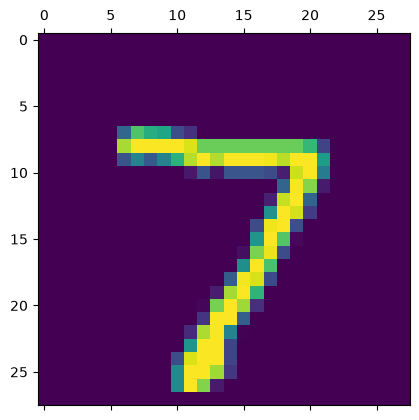

In [32]:
plt.matshow(X_test[0])

In [33]:
print(np.argmax(y_predict[1234]))

8


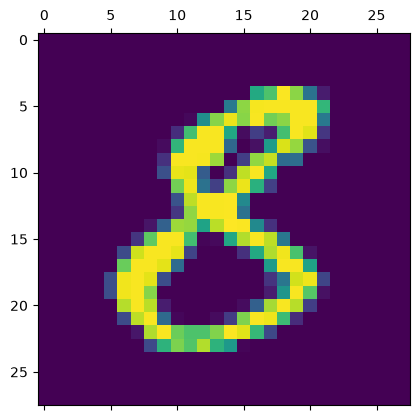

In [34]:
plt.matshow(X_test[1234])

In [35]:
# Now lets export model using keras
model.save("digit_recognition_model.keras")